In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# load the data
df = pd.read_csv('../datasets/FuelConsumptionCo2.csv')

In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [5]:
# Extract Features and Target
X = df.FUELCONSUMPTION_COMB.to_numpy()
y = df.CO2EMISSIONS.to_numpy()

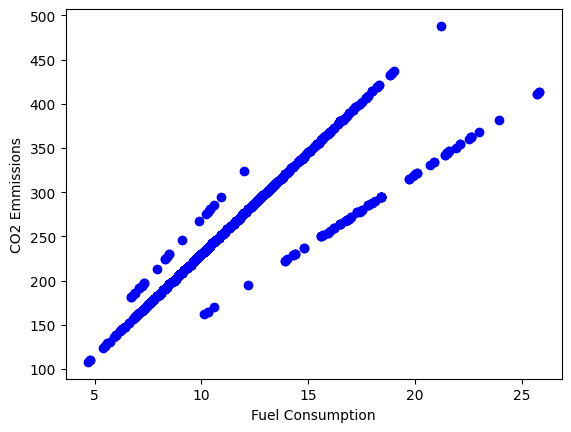

In [7]:
# Visualize
plt.scatter(X,y, color='blue')
plt.xlabel('Fuel Consumption')
plt.ylabel('CO2 Emmissions')
plt.show()

In [13]:
# split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'Shapes:\n X_train - {X_train.shape} \n X_test - {X_test.shape} \n y_train - {y_train.shape} \n y_test - {y_test.shape}')

Shapes:
 X_train - (853,) 
 X_test - (214,) 
 y_train - (853,) 
 y_test - (214,)


In [16]:
# Build the Simple Linear Regression model
from sklearn import linear_model
regressor = linear_model.LinearRegression()
regressor.fit(X_train.reshape(-1,1),y_train)
slope = regressor.coef_[0]
intercept = regressor.intercept_

# Print slope and intercept of the straight line
print(f'Slope: {slope}' )
print(f'Intercept: {intercept}')

Slope: 16.18090078119919
Intercept: 69.10302617988452


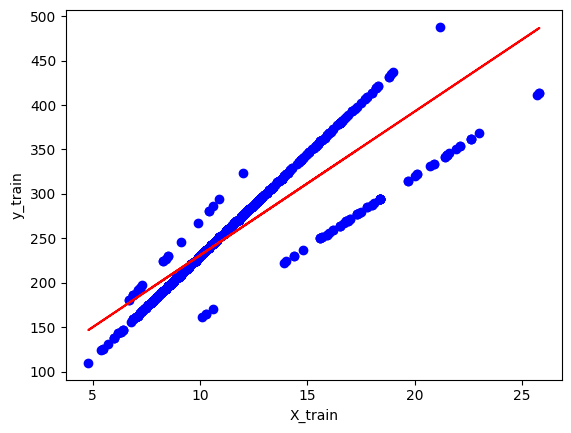

In [20]:
# Visualize the model against training dataset
plt.scatter(X_train,y_train,color='blue')
plt.plot(X_train, slope*X_train + intercept, '-r')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.show()

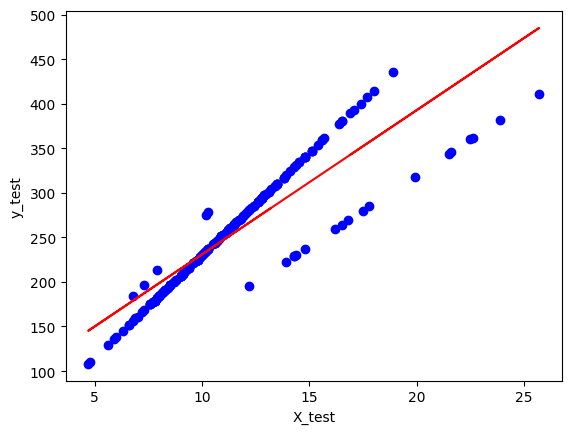

In [21]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred = regressor.predict(X_test.reshape(-1,1))
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred,'-r')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.show()

In [22]:
# Evaluation scores
print(f'MAE: {mean_absolute_error(y_test,y_pred)}')
print(f'MSE: {mean_squared_error(y_test,y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test,y_pred))}')
print(f'R2 Score: {r2_score(y_test,y_pred)}')

MAE: 20.441911472549585
MSE: 797.4346310097205
RMSE: 28.238885087937174
R2 Score: 0.8071474868274242
